In [44]:
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset

# import datasetfromtensor from pytorch



from sklearn.datasets import fetch_openml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import seaborn as sns
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from sktime.datasets import load_airline

EPOCHS = 5
LEARNING_RATE = 0.001

DEVICE = "cpu"
if torch.cuda.is_available():
    DEVICE = "cuda"
    print("CUDA device found.", torch.cuda.is_available())
    EPOCHS = 20
elif torch.backends.mps.is_available():
    DEVICE = "mps"
    print ("MPS device found.", torch.backends.mps.is_available())
    EPOCHS = 25
else:
    print("Using CPU device.")
    #BATCH_SIZE = 64

MPS device found. True


# A Simple Example of RNN and LSTM

<Axes: xlabel='Period'>

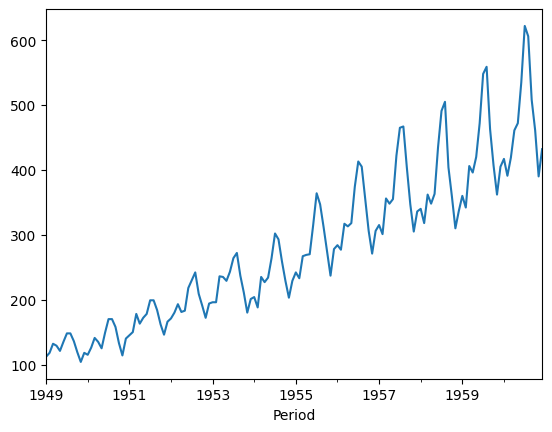

In [45]:
y = load_airline()
scaler = MinMaxScaler()
y_scaled = scaler.fit_transform(y.values.reshape(-1, 1))
y.plot()

### Construct Sequences for Time Series Data

Our data is a listing of values, but we need to convert it into sequences of data for our RNN and LSTM models. We will create a function to do this. The two parameters are the lookback, which is how many previous time steps we want to use as input, and the prediction length, which is how many future time steps we want to predict in one step. For now, we'll leave the prediction length at 1. 

In [46]:
def create_sequences(data, lookback=36, prediction_length=1):
    xs, ys = [], []
    for i in range(len(data) - lookback - prediction_length + 1):
        x = data[i:(i + lookback)]
        y = data[(i + lookback):(i + lookback + prediction_length)]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

x_flight, y_flight = create_sequences(y_scaled, lookback=36, prediction_length=1)
print("Input sequence shape:", x_flight.shape)
print("Output sequence shape:", y_flight.shape)
print("First input sequence:", x_flight[0])
print("First output value:", y_flight[0])

Input sequence shape: (108, 36, 1)
Output sequence shape: (108, 1, 1)
First input sequence: [[0.01544402]
 [0.02702703]
 [0.05405405]
 [0.04826255]
 [0.03281853]
 [0.05984556]
 [0.08494208]
 [0.08494208]
 [0.06177606]
 [0.02895753]
 [0.        ]
 [0.02702703]
 [0.02123552]
 [0.04247104]
 [0.07142857]
 [0.05984556]
 [0.04054054]
 [0.08687259]
 [0.12741313]
 [0.12741313]
 [0.1042471 ]
 [0.05598456]
 [0.01930502]
 [0.06949807]
 [0.07915058]
 [0.08880309]
 [0.14285714]
 [0.11389961]
 [0.13127413]
 [0.14285714]
 [0.18339768]
 [0.18339768]
 [0.15444015]
 [0.11196911]
 [0.08108108]
 [0.11969112]]
First output value: [[0.12934363]]


### Construct Datasets

In [47]:
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y)
        if X.ndim == 2:                 # (N, seq_len) -> (N, seq_len, 1)
            X = X[..., None]
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).float()
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

test_data_share = 0.2
test_size = int(len(x_flight) * test_data_share)
train_X, test_X = x_flight[:-test_size], x_flight[-test_size:]
train_y, test_y = y_flight[:-test_size], y_flight[-test_size:]
print("Train X shape:", train_X.shape)
print("Train y shape:", train_y.shape)
print("Test X shape:", test_X.shape)
print("Test y shape:", test_y.shape)

Train X shape: (87, 36, 1)
Train y shape: (87, 1, 1)
Test X shape: (21, 36, 1)
Test y shape: (21, 1, 1)


In [48]:
train_dataset = TimeSeriesDataset(train_X, train_y)
test_dataset = TimeSeriesDataset(test_X, test_y)

batch_size = 4
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

## Create a Model

### RNN

### RNN - The Important Bits

This is an explainer of what you need to get started. 

**Model Creation**
- **`input_size`**: Number of features at each timestep (e.g., 1 for univariate time series). This is the last dimension of the input tensor. This simple example just has one feature, and this will always be 1 for univariate forecasting.
- **`hidden_size`**: Number of features in the RNN hidden state — controls the capacity of the recurrent layer.
- **`num_layers`**: Number of stacked RNN layers. Stacking increases model depth.
- **`output_size`**: Number of features in the output (e.g., `prediction_length` for multi-step forecasting, or number of target variables).

- **RNN layer (`nn.RNN` )**: The recurrent module that processes the sequence. Important args:  
  - `batch_first=True` means inputs use shape `(batch, seq_len, input_size)`. This is more intuitive for time series data and matches our dataset format. If `False`, the expected shape is `(seq_len, batch, input_size)`.
  - `bidirectional` doubles the hidden outputs (forward+backward) and changes shapes accordingly.  
  - `dropout` is set the dropout percentage if there are 2 or more layers. Accepts values between 0 and 1. 

- **`fc` (fully connected) layer**: Maps from the RNN hidden dimension (often the last timestep's output or the last hidden state) to the desired `output_size` (e.g., prediction length or number of target variables).

**`forward(self, x, h0=None)`**
- **Input shape**: Expect `x` of shape `(batch, seq_len, input_size)` when `batch_first=True`.
- **Call to RNN**: `out, h_n = self.rnn(x, h0)` returns:  
  - `out` shape: `(batch, seq_len, hidden_size * num_directions)` when `batch_first=True`.  
  - `h_n` shape: `(num_layers * num_directions, batch, hidden_size)`.

- **Choosing what to send to `fc`**:  
  - Common approach for sequence-to-one forecasting: take the last timestep output: `last = out[:, -1, :]` then `pred = self.fc(last)`.  
  - Alternative: use the last layer's hidden state `h_n` — this provides the "short-term memory" as an output. This is used more in sequence-to-sequence tasks such as translation. 

- **Output shape**: After `fc`, shape typically `(batch, output_size)` for one-step predictions.
- **Return values**: Return `pred` (and optionally `h_n` for stateful RNN usage).

In [49]:
class SimpleRNN(nn.Module):
    def __init__(self, input_size=1, hidden_size=16, output_size=1):
        super(SimpleRNN, self).__init__()
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
    def forward(self, x):
        rnn_out, _ = self.rnn(x) # out: (batch, seq_len, hidden*dir)
        last_time_step = rnn_out[:, -1, :]
        out = self.fc(last_time_step)
        return out
    def recursive_predict(self, x, prediction_length):
        self.eval()
        predictions = []
        current_input = x
        for _ in range(prediction_length):
            with torch.no_grad():
                pred = self.forward(current_input)
                predictions.append(pred.cpu().numpy())
                # Prepare next input: remove first time step and append prediction
                pred_reshaped = pred.unsqueeze(1)  # (batch, 1, output_size)
                current_input = torch.cat((current_input[:, 1:, :], pred_reshaped), dim=1)
        return np.array(predictions).squeeze()

## LSTM

**LSTM — Component Guide (Detailed explanation)**

This should be enough to get you started with LSTM.

**Model Creation**
- The recurrent layer is `nn.LSTM(input_size, hidden_size, num_layers, ...)`. It maintains two tensors per layer: the hidden state `h_t` and the cell state `c_t`.
- `batch_first=True` means inputs use shape `(batch, seq_len, input_size)` which aligns with most DataLoader outputs.
- If `bidirectional=True`, the LSTM runs forward and backward; the effective output and hidden dimensions are doubled (forward + backward). Ensure downstream layers account for that.
- The `fc` layer maps the chosen LSTM representation (commonly the last timestep output or the last layer's hidden state) to the `output_size` (e.g., 1 for single-step forecasting).

**Forward Pass**
- `out, (h_n, c_n) = self.lstm(x)` (You can initialize hidden/cell states with `h0, c0` if desired; otherwise, PyTorch defaults to zeros).
- `out` shape (batch_first=True): `(batch, seq_len, hidden_size * num_directions)` — outputs for each timestep from the last layer.
- `h_n` shape: `(num_layers * num_directions, batch, hidden_size)` — final hidden state per layer and direction.
- `c_n` shape: same as `h_n` — final cell state per layer and direction.

**Generating Output**
- Common approach (sequence→one): take the last timestep output `last = out[:, -1, :]` then `pred = self.fc(last)`.
- Alternative: use the last layer hidden `h_n` (reshape to extract last layer and flatten directions) — this is useful when stacking layers or working with bidirectionality. A bidirectionality example would look like this:
- ```python
  # For bidirectional, h_n has shape (num_layers * 2, batch, hidden_size)
  # To get the last layer's forward and backward hidden states:
  forward_h = h_n[-2, :, :]  # Last layer's forward hidden state
  backward_h = h_n[-1, :, :]   # Last layer's backward hidden state
  last = torch.cat((forward_h, backward_h), dim=1)  # Concatenate for fc input
  pred = self.fc(last)  
  ```

In [50]:
class SimpleLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=16, output_size=1):
        super(SimpleLSTM, self).__init__()
        self.rnn = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
    def forward(self, x):
        lstm_output, (h_n, c_n) = self.rnn(x) # lstm_output: (batch, seq_len, hidden*dir)
        # States: h_n: (num_layers*dir, batch, hidden), c_n: (num_layers*dir, batch, hidden)
        last_time_step = lstm_output[:, -1, :]
        out = self.fc(last_time_step)
        return out
    def recursive_predict(self, x, prediction_length):
        self.eval()
        predictions = []
        current_input = x
        for _ in range(prediction_length):
            with torch.no_grad():
                pred = self.forward(current_input)
                predictions.append(pred.cpu().numpy())
                # Prepare next input: drop first time step, append prediction
                current_input = torch.cat([current_input[:, 1:, :], pred.unsqueeze(1)], dim=1)
        return np.array(predictions).squeeze()

## Training Loop and Evaluation

In [51]:
def train(model, training_dataloader, test_dataloader, epochs=5, learning_rate=0.001, output_length=1):
    model.to(DEVICE)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    last_epoch_train_predictions = []
    last_epoch_test_predictions = []
    with torch.set_grad_enabled(True):
        for i, epoch in enumerate(range(epochs)):
            model.train()
            train_losses = []
            for batch_X, batch_y in training_dataloader:
                batch_X, batch_y = batch_X.to(DEVICE), batch_y.to(DEVICE)
                optimizer.zero_grad()
                predictions = model(batch_X).squeeze()
                loss = criterion(predictions, batch_y.squeeze())
                loss.backward()
                optimizer.step()
                train_losses.append(loss.item())
                if i == epochs - 1:
                    last_epoch_train_predictions.append(predictions.detach().cpu().numpy())
            avg_train_loss = np.mean(train_losses)
            model.eval()
            test_losses = []
            with torch.no_grad():
                for batch_X, batch_y in test_dataloader:
                    batch_X, batch_y = batch_X.to(DEVICE), batch_y.to(DEVICE)
                    predictions = model(batch_X).squeeze()
                    loss = criterion(predictions, batch_y.squeeze())
                    test_losses.append(loss.item())
                    if i == epochs - 1:
                        last_epoch_test_predictions.append(predictions.detach().cpu().numpy())
            avg_test_loss = np.mean(test_losses)
            print(f"Epoch {epoch+1}/{epochs} - Train Loss: {avg_train_loss:.4f} - Test Loss: {avg_test_loss:.4f}")
    return last_epoch_train_predictions, last_epoch_test_predictions

In [52]:
predictions_with_offsets = {}
# Train RNN
simple_rnn_model = SimpleRNN(input_size=1, hidden_size=16, output_size=1)
rnn_tp, rnn_tep = train(simple_rnn_model, train_loader, test_loader, epochs=EPOCHS, learning_rate=LEARNING_RATE)
predictions_with_offsets["RNN_train"] = (rnn_tp, 36)
predictions_with_offsets["RNN_test"] = (rnn_tep, 36 + len(train_X))
print("RNN", rnn_tep)

Epoch 1/25 - Train Loss: 0.1742 - Test Loss: 0.2825
Epoch 2/25 - Train Loss: 0.0114 - Test Loss: 0.0557
Epoch 3/25 - Train Loss: 0.0330 - Test Loss: 0.0941
Epoch 4/25 - Train Loss: 0.0216 - Test Loss: 0.0847
Epoch 5/25 - Train Loss: 0.0209 - Test Loss: 0.0770
Epoch 6/25 - Train Loss: 0.0206 - Test Loss: 0.0742
Epoch 7/25 - Train Loss: 0.0194 - Test Loss: 0.0694
Epoch 8/25 - Train Loss: 0.0185 - Test Loss: 0.0651
Epoch 9/25 - Train Loss: 0.0176 - Test Loss: 0.0610
Epoch 10/25 - Train Loss: 0.0167 - Test Loss: 0.0569
Epoch 11/25 - Train Loss: 0.0158 - Test Loss: 0.0528
Epoch 12/25 - Train Loss: 0.0149 - Test Loss: 0.0488
Epoch 13/25 - Train Loss: 0.0141 - Test Loss: 0.0449
Epoch 14/25 - Train Loss: 0.0133 - Test Loss: 0.0410
Epoch 15/25 - Train Loss: 0.0125 - Test Loss: 0.0373
Epoch 16/25 - Train Loss: 0.0117 - Test Loss: 0.0336
Epoch 17/25 - Train Loss: 0.0109 - Test Loss: 0.0301
Epoch 18/25 - Train Loss: 0.0101 - Test Loss: 0.0269
Epoch 19/25 - Train Loss: 0.0094 - Test Loss: 0.0240
Ep

In [53]:
# Train LSTM
simple_lstm_model = SimpleLSTM(input_size=1, hidden_size=16, output_size=1)
lstm_tp, lstm_tep = train(simple_lstm_model, train_loader, test_loader, epochs=EPOCHS, learning_rate=LEARNING_RATE)
predictions_with_offsets["LSTM_train"] = (lstm_tp, 36)
predictions_with_offsets["LSTM_test"] = (lstm_tep, 36 + len(train_X))
print("test_predictions:", lstm_tep)


Epoch 1/25 - Train Loss: 0.1091 - Test Loss: 0.2899
Epoch 2/25 - Train Loss: 0.0399 - Test Loss: 0.1401
Epoch 3/25 - Train Loss: 0.0131 - Test Loss: 0.0589
Epoch 4/25 - Train Loss: 0.0210 - Test Loss: 0.0700
Epoch 5/25 - Train Loss: 0.0176 - Test Loss: 0.0658
Epoch 6/25 - Train Loss: 0.0166 - Test Loss: 0.0591
Epoch 7/25 - Train Loss: 0.0161 - Test Loss: 0.0546
Epoch 8/25 - Train Loss: 0.0152 - Test Loss: 0.0492
Epoch 9/25 - Train Loss: 0.0143 - Test Loss: 0.0436
Epoch 10/25 - Train Loss: 0.0134 - Test Loss: 0.0379
Epoch 11/25 - Train Loss: 0.0125 - Test Loss: 0.0321
Epoch 12/25 - Train Loss: 0.0115 - Test Loss: 0.0268
Epoch 13/25 - Train Loss: 0.0105 - Test Loss: 0.0230
Epoch 14/25 - Train Loss: 0.0097 - Test Loss: 0.0217
Epoch 15/25 - Train Loss: 0.0091 - Test Loss: 0.0216
Epoch 16/25 - Train Loss: 0.0088 - Test Loss: 0.0214
Epoch 17/25 - Train Loss: 0.0087 - Test Loss: 0.0213
Epoch 18/25 - Train Loss: 0.0086 - Test Loss: 0.0211
Epoch 19/25 - Train Loss: 0.0085 - Test Loss: 0.0210
Ep

In [54]:
# Using recursive prediction for longer horizon

seed_x = torch.from_numpy(test_X[0:1]).float().to(DEVICE)  # Take first test sequence as seed
prediction_length = 12
lstm_long_preds = simple_lstm_model.recursive_predict(seed_x, prediction_length)
print("LSTM Long Test preds example:", lstm_long_preds)

LSTM Long Test preds example: [0.5523874  0.55668336 0.561104   0.5654643  0.5697734  0.57405216
 0.5783189  0.5825713  0.5868023  0.5909754  0.595107   0.5992105 ]


## Longer Predictions

Each of these examples is the same as prior, but we set `output_length=prediction_length`, so each individual prediction changes from one value to a vector of M values, each being one individual prediction. This setup generates all the predictions at once, so if we want to look into the future 12 steps, we get all 12 predictions at once, without the recursion. 

Note that the output is now a different shape, so we need to account for that. Each prediction isn't a value for the next month, each prediction is a vector of 12 predictions for the next year. If we want to deal with that, we need to consider a couple of things:
<ul>
<li> How should the error calculations work. Right now, each prediction is counted equally. Would it be better to weight things so "tomorrow's" prediction is more important than "11 months from now"?</li>
<li> Since each prediction is now several predictions, if we want to do somehting like plot the predictions, we need to account for that. 
</ul>

In [55]:
# Longer Predictions
prediction_length = 12

long_x_train, long_y_train = create_sequences(y_scaled, lookback=36, prediction_length=prediction_length)
long_x_test, long_y_test = create_sequences(y_scaled, lookback=36, prediction_length=prediction_length)

long_train_dataset = TimeSeriesDataset(long_x_train, long_y_train)
long_test_dataset = TimeSeriesDataset(long_x_test, long_y_test)

long_train_loader = DataLoader(long_train_dataset, batch_size=batch_size, shuffle=False)
long_test_loader = DataLoader(long_test_dataset, batch_size=batch_size, shuffle=False)

print("Longer Train X shape:", long_x_train.shape)
print("Longer Train y shape:", long_y_train.shape)
print("Longer Test X shape:", long_x_test.shape)
print("Longer Test y shape:", long_y_test.shape)

Longer Train X shape: (97, 36, 1)
Longer Train y shape: (97, 12, 1)
Longer Test X shape: (97, 36, 1)
Longer Test y shape: (97, 12, 1)


In [56]:
# Train RNN
simple_rnn_model = SimpleRNN(input_size=1, hidden_size=16, output_size=prediction_length)
rnn_tpL, rnn_tepL = train(simple_rnn_model, long_train_loader, long_test_loader, epochs=EPOCHS, learning_rate=LEARNING_RATE, output_length=prediction_length)
predictions_with_offsets["RNN_Long_Train"] = (rnn_tpL, 36)
predictions_with_offsets["RNN_Long_Test"] = (rnn_tepL, 36 + len(train_X))
print("RNN longer test predictions:", rnn_tepL)

Epoch 1/25 - Train Loss: 0.1691 - Test Loss: 0.1150
Epoch 2/25 - Train Loss: 0.0741 - Test Loss: 0.0522
Epoch 3/25 - Train Loss: 0.0446 - Test Loss: 0.0356
Epoch 4/25 - Train Loss: 0.0389 - Test Loss: 0.0319
Epoch 5/25 - Train Loss: 0.0372 - Test Loss: 0.0310
Epoch 6/25 - Train Loss: 0.0364 - Test Loss: 0.0304
Epoch 7/25 - Train Loss: 0.0357 - Test Loss: 0.0297
Epoch 8/25 - Train Loss: 0.0349 - Test Loss: 0.0291
Epoch 9/25 - Train Loss: 0.0341 - Test Loss: 0.0284
Epoch 10/25 - Train Loss: 0.0333 - Test Loss: 0.0277
Epoch 11/25 - Train Loss: 0.0325 - Test Loss: 0.0269
Epoch 12/25 - Train Loss: 0.0315 - Test Loss: 0.0261
Epoch 13/25 - Train Loss: 0.0306 - Test Loss: 0.0252
Epoch 14/25 - Train Loss: 0.0296 - Test Loss: 0.0243
Epoch 15/25 - Train Loss: 0.0285 - Test Loss: 0.0234
Epoch 16/25 - Train Loss: 0.0273 - Test Loss: 0.0224
Epoch 17/25 - Train Loss: 0.0261 - Test Loss: 0.0214
Epoch 18/25 - Train Loss: 0.0249 - Test Loss: 0.0203
Epoch 19/25 - Train Loss: 0.0235 - Test Loss: 0.0192
Ep

In [66]:
# Train LSTM
simple_lstm_model = SimpleLSTM(input_size=1, hidden_size=16, output_size=prediction_length)
lstm_tpL, lstm_tepL = train(simple_lstm_model, long_train_loader, long_test_loader, epochs=EPOCHS, learning_rate=LEARNING_RATE, output_length=prediction_length)
predictions_with_offsets["LSTM_Long_Train"] = (lstm_tpL, 36)
predictions_with_offsets["LSTM_Long_Test"] = (lstm_tepL, 36 + len(train_X))
print("LSTM Long Test preds example:", lstm_tepL.shape, lstm_tepL)

Epoch 1/25 - Train Loss: 0.1609 - Test Loss: 0.1350
Epoch 2/25 - Train Loss: 0.0923 - Test Loss: 0.0660
Epoch 3/25 - Train Loss: 0.0401 - Test Loss: 0.0444
Epoch 4/25 - Train Loss: 0.0477 - Test Loss: 0.0334
Epoch 5/25 - Train Loss: 0.0336 - Test Loss: 0.0314
Epoch 6/25 - Train Loss: 0.0358 - Test Loss: 0.0300
Epoch 7/25 - Train Loss: 0.0336 - Test Loss: 0.0291
Epoch 8/25 - Train Loss: 0.0327 - Test Loss: 0.0281
Epoch 9/25 - Train Loss: 0.0315 - Test Loss: 0.0271
Epoch 10/25 - Train Loss: 0.0304 - Test Loss: 0.0260
Epoch 11/25 - Train Loss: 0.0291 - Test Loss: 0.0247
Epoch 12/25 - Train Loss: 0.0277 - Test Loss: 0.0234
Epoch 13/25 - Train Loss: 0.0261 - Test Loss: 0.0218
Epoch 14/25 - Train Loss: 0.0242 - Test Loss: 0.0201
Epoch 15/25 - Train Loss: 0.0218 - Test Loss: 0.0182
Epoch 16/25 - Train Loss: 0.0190 - Test Loss: 0.0161
Epoch 17/25 - Train Loss: 0.0162 - Test Loss: 0.0141
Epoch 18/25 - Train Loss: 0.0154 - Test Loss: 0.0145
Epoch 19/25 - Train Loss: 0.0147 - Test Loss: 0.0143
Ep

AttributeError: 'list' object has no attribute 'shape'

## (Maybe Not So) Fun Exercise

Create a function to correctly plot things, no matter the shape of the predictions or the batches. 